In [7]:
# pip install seaborn
# !pip install scikit-learn

import necessary library

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error, mean_absolute_error
import pickle


import warnings
warnings.filterwarnings("ignore")

In [9]:
df = pd.read_csv("data.csv")
df.head()

,x,y
0,48.955889,60.723602
1,44.687196,82.892504
2,60.297327,97.379897
3,45.618644,48.847153
4,38.816818,56.877213


In [10]:
# rename the column
df = df.rename(columns={"x":"quantity", "y":"price"})

In [11]:
df.head()

,quantity,price
0,48.955889,60.723602
1,44.687196,82.892504
2,60.297327,97.379897
3,45.618644,48.847153
4,38.816818,56.877213


In [12]:
df1 = df.copy()

initial analysis

In [13]:
df.isna().sum()

quantity    0
price       0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df["price"].min()

np.float64(41.4128853)

In [16]:
df.describe()

,quantity,price
count,99.000000,99.000000
mean,49.124564,73.149475
std,9.652463,16.216558
min,25.128485,41.412885
25%,41.648159,61.088576
50%,50.030174,72.247251
75%,56.798054,83.287411
max,70.346076,118.591217


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   quantity  99 non-null     float64
 1   price     99 non-null     float64
dtypes: float64(2)
memory usage: 1.7 KB


In [18]:
df.corr()

,quantity,price
quantity,1.000000,0.766264
price,0.766264,1.000000


<Axes: >

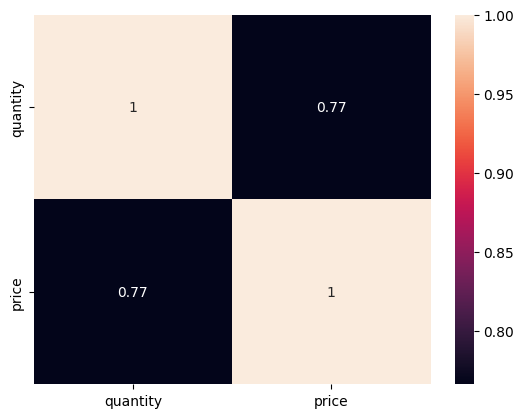

In [19]:
sns.heatmap(df.corr(),annot=True)

Data visualization

In [20]:
df.head(1)

,quantity,price
0,48.955889,60.723602


<Axes: ylabel='price'>

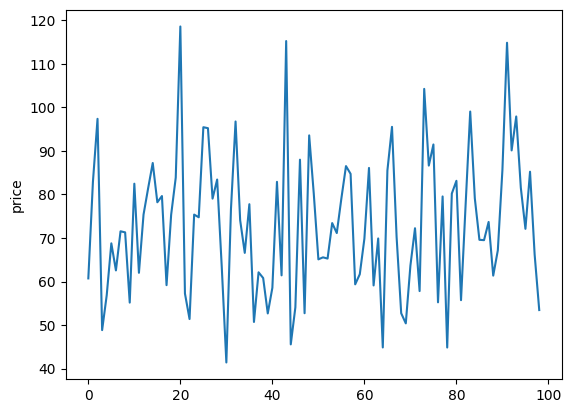

In [21]:
sns.lineplot(df["price"])

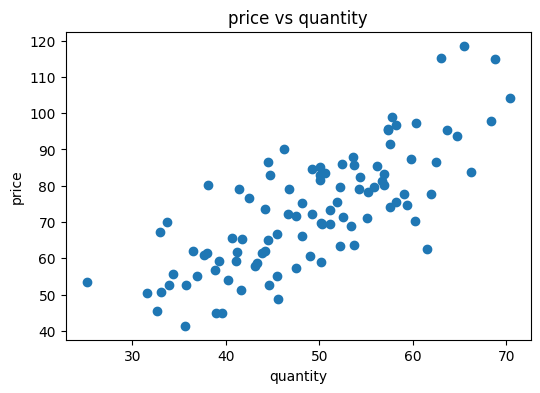

In [22]:
plt.figure(figsize=(6,4))
plt.scatter(df["quantity"],df["price"])
plt.xlabel("quantity")
plt.ylabel("price")
plt.title("price vs quantity")
plt.show()

In [23]:
# separate the dataset
x =df[["quantity"]]
y = df[["price"]]

In [24]:
# split the dataset
xtrain, xtest, ytrain,ytest = train_test_split(x,y, test_size=.2, random_state=42)

In [25]:
xtrain.shape,ytrain.shape, xtest.shape, ytest.shape

((79, 1), (79, 1), (20, 1), (20, 1))

In [26]:
xtrain.head()

,quantity
49,38.119824
70,53.660932
68,35.678094
15,55.142188
39,44.555608


In [27]:
ytrain.head()

,price
49,80.166275
70,63.642399
68,52.721735
15,78.211518
39,52.682983


In [28]:
xtest

,quantity
62,50.135485
40,43.318283
95,49.239765
18,48.105042
97,48.149859
84,54.282329
64,39.557901
42,43.870613
10,54.351635
0,48.955889


In [29]:
ytest

,price
62,59.108839
40,58.569825
95,72.111832
18,75.331242
97,66.224958
84,79.120646
64,44.862491
42,61.424710
10,82.478847
0,60.723602


In [30]:
# model training
lr = LinearRegression()

In [31]:
model= lr.fit(xtrain, ytrain)

In [32]:
# accuracy measure
model.score(xtrain, ytrain)

0.5351098913885504

In [33]:
# check the test result
model.score(xtest, ytest)

0.692783029905275

In [34]:
# prediction generate
model.predict([[38.11]])

array([[60.58950521]])

In [35]:
y_pred = model.predict(xtest)

In [36]:
y_pred

array([[ 75.29719392],
       [ 66.95946006],
       [ 74.20168945],
       [ 72.81387336],
       [ 72.86868674],
       [ 80.36896248],
       [ 62.36035101],
       [ 67.63498356],
       [ 80.45372692],
       [ 73.85449589],
       [ 65.88097358],
       [ 59.14640789],
       [ 55.39672654],
       [ 91.78390943],
       [ 53.93498047],
       [ 61.45397362],
       [ 64.82813598],
       [ 85.12188219],
       [ 60.46168253],
       [100.01561951]])

In [37]:
ytest

,price
62,59.108839
40,58.569825
95,72.111832
18,75.331242
97,66.224958
84,79.120646
64,44.862491
42,61.424710
10,82.478847
0,60.723602


In [38]:
# prediction for the total price
df["error"]= ytest- y_pred

In [39]:
y_price = model.predict(x)

In [40]:
df["error_total"]= y-y_price
df.head()

,quantity,price,error,error_total
0,48.955889,60.723602,-13.130893,-13.130893
1,44.687196,82.892504,NaN,14.258803
2,60.297327,97.379897,NaN,9.654332
3,45.618644,48.847153,NaN,-20.925748
4,38.816818,56.877213,-4.576760,-4.576760


In [41]:
df= df.drop(["error"], axis= 1)
df.head()

,quantity,price,error_total
0,48.955889,60.723602,-13.130893
1,44.687196,82.892504,14.258803
2,60.297327,97.379897,9.654332
3,45.618644,48.847153,-20.925748
4,38.816818,56.877213,-4.576760


In [42]:
len(df["price"])

99

In [43]:
# mse = sum((df["price"] - y_price)**2) / len(df[["price"]])

In [44]:
# evaluate the model
r_score = r2_score(ytest, y_pred)
r_score

0.692783029905275

In [45]:
# pred with user input
test_data = float(input("enter  any valid qauntity of the product   "))
model.predict([[test_data]])

array([[197.4358131]])

In [46]:
df.columns

Index(['quantity', 'price', 'error_total'], dtype='object')

In [47]:
# test with data frame
test_dic = {"quantity": [40]}
data = pd.DataFrame(test_dic)
data

,quantity
0,40


In [48]:
model.predict(data)

array([[62.90105693]])

In [49]:
# cost of the model
mse = mean_squared_error(ytest, y_pred)
mse

72.23130683527735

In [50]:
mae = mean_absolute_error(ytest, y_pred)
mae

6.898123580553088

In [51]:
# find the value of m

c = model.intercept_
c

array([13.97932742])

In [52]:
m = model.coef_
m

array([[1.22304324]])

In [53]:
yy = m * 40 +c
yy

array([[62.90105693]])

In [54]:
df.head()

,quantity,price,error_total
0,48.955889,60.723602,-13.130893
1,44.687196,82.892504,14.258803
2,60.297327,97.379897,9.654332
3,45.618644,48.847153,-20.925748
4,38.816818,56.877213,-4.576760


find the best fit line

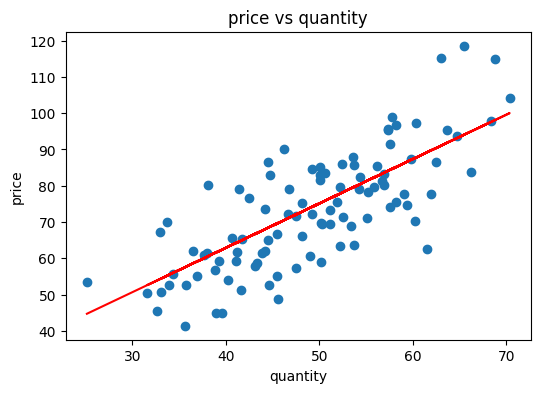

In [55]:
plt.figure(figsize=(6,4))
plt.scatter(df["quantity"],df["price"])
plt.plot(x, model.predict(x), color= "r")
plt.xlabel("quantity")
plt.ylabel("price")
plt.title("price vs quantity")
plt.show()

In [56]:
df.head(10)

,quantity,price,error_total
0,48.955889,60.723602,-13.130893
1,44.687196,82.892504,14.258803
2,60.297327,97.379897,9.654332
3,45.618644,48.847153,-20.925748
4,38.816818,56.877213,-4.576760
5,53.426804,68.777596,-10.545023
6,61.530358,62.562382,-26.671233
7,47.475640,71.546632,-0.497455
8,52.550014,71.300880,-6.949387
9,45.419730,55.165677,-14.363944


In [57]:
df.loc[5:15]

,quantity,price,error_total
5,53.426804,68.777596,-10.545023
6,61.530358,62.562382,-26.671233
7,47.475640,71.546632,-0.497455
8,52.550014,71.300880,-6.949387
9,45.419730,55.165677,-14.363944
10,54.351635,82.478847,2.025120
11,44.164049,62.008923,-5.984946
12,58.168471,75.392870,-9.729012
13,56.727208,81.436192,-1.922963
14,59.813208,87.230925,0.097458


In [58]:
df.iloc[5:15]

,quantity,price,error_total
5,53.426804,68.777596,-10.545023
6,61.530358,62.562382,-26.671233
7,47.475640,71.546632,-0.497455
8,52.550014,71.300880,-6.949387
9,45.419730,55.165677,-14.363944
10,54.351635,82.478847,2.025120
11,44.164049,62.008923,-5.984946
12,58.168471,75.392870,-9.729012
13,56.727208,81.436192,-1.922963
14,59.813208,87.230925,0.097458


In [59]:
# model save
pickle.dump(model, open("my_first_model.pkl", "wb"))